In [1]:
import sys
import json
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository root (the directory that contains simulation_engine) so the
# notebook runs regardless of the directory Jupyter was launched from.
repository_path = pathlib.Path.cwd()
while not (repository_path / "simulation_engine").is_dir() and repository_path != repository_path.parent:
    repository_path = repository_path.parent
machine_learning_path = repository_path / "notebooks" / "machine_learning"
for path_entry in (str(repository_path), str(machine_learning_path)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

import rl_helpers.rl_plots as rl_plots

data_rl_path = repository_path / "data" / "rl"

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 4 - Evaluation against the baseline

This is the headline comparison. Each learned policy is evaluated against the rule-based baseline
on the **same** held-out seeds, so every game starts from an identical deal and deck and differs
only in the decisions taken. That pairing lets us use a McNemar test on the discordant outcomes,
and Wilson score intervals quantify each win rate.

## Statistics

For a win rate $\hat{p} = w / n$ the **Wilson score interval** gives an asymmetric confidence
interval that behaves well even near 0 or 1:

$$\frac{\hat{p} + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}.$$

Because the comparison is paired by seed, we use **McNemar's test**. Let $b$ be the games the
learned policy wins but the baseline loses, and $c$ the reverse. Only those discordant pairs carry
information; the continuity-corrected statistic $\chi^2 = (|b-c|-1)^2 / (b+c)$ has one degree of
freedom. These match `statsmodels` but are implemented in pure Python in the engine package.

In [2]:
ablations = manifest_ablations = json.loads((data_rl_path / 'manifest.json').read_text())['ablations']
player_counts = json.loads((data_rl_path / 'manifest.json').read_text())['player_counts']
update_rules = json.loads((data_rl_path / 'manifest.json').read_text())['update_rules']

def load_eval(ablation, update_rule, player_count):
    return json.loads((data_rl_path / f'eval_{ablation}_{update_rule}_pc{player_count}.json').read_text())

summary_rows = []
for ablation in ablations:
    for update_rule in update_rules:
        for player_count in player_counts:
            summary = load_eval(ablation, update_rule, player_count)
            summary_rows.append({
                'ablation': ablation,
                'update_rule': update_rule,
                'players': player_count,
                'baseline': round(summary['baseline_win_rate'], 3),
                'learned': round(summary['rl_win_rate'], 3),
                'delta': round(summary['rl_win_rate'] - summary['baseline_win_rate'], 3),
                'mcnemar_p': round(summary['mcnemar']['p_value'], 3),
            })
summary_frame = pd.DataFrame(summary_rows)
summary_frame

,ablation,update_rule,players,baseline,learned,delta,mcnemar_p
0,mission_only,q_learning,6,0.329,0.363,0.034,0.000
1,mission_only,q_learning,7,0.331,0.390,0.059,0.000
2,mission_only,q_learning,8,0.408,0.507,0.099,0.000
3,mission_only,sarsa,6,0.329,0.391,0.062,0.000
4,mission_only,sarsa,7,0.331,0.429,0.098,0.000
5,mission_only,sarsa,8,0.408,0.516,0.108,0.000
6,participant_only,q_learning,6,0.329,0.299,-0.029,0.002
7,participant_only,q_learning,7,0.331,0.282,-0.049,0.000
8,participant_only,q_learning,8,0.408,0.364,-0.045,0.000
9,participant_only,sarsa,6,0.329,0.283,-0.045,0.000


## Win rate by player count and ablation

Grouped bars compare the learned policy (Q-learning) against the baseline for each ablation, with
Wilson 95% intervals as error bars. Overlapping intervals indicate the difference is within noise.

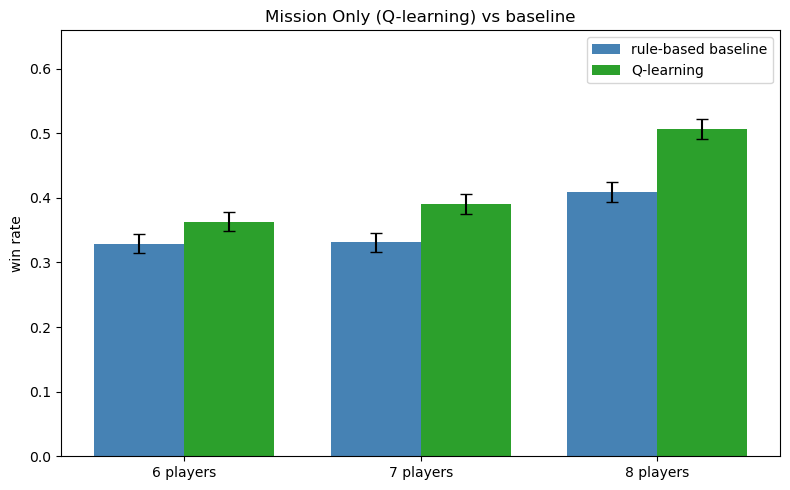

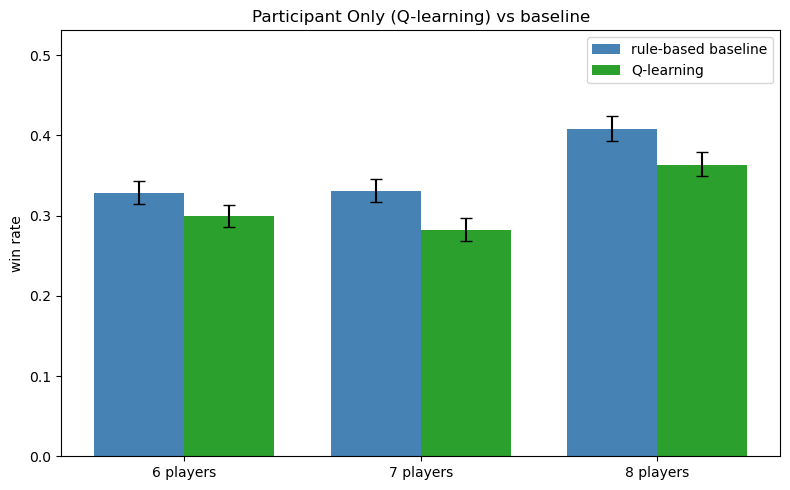

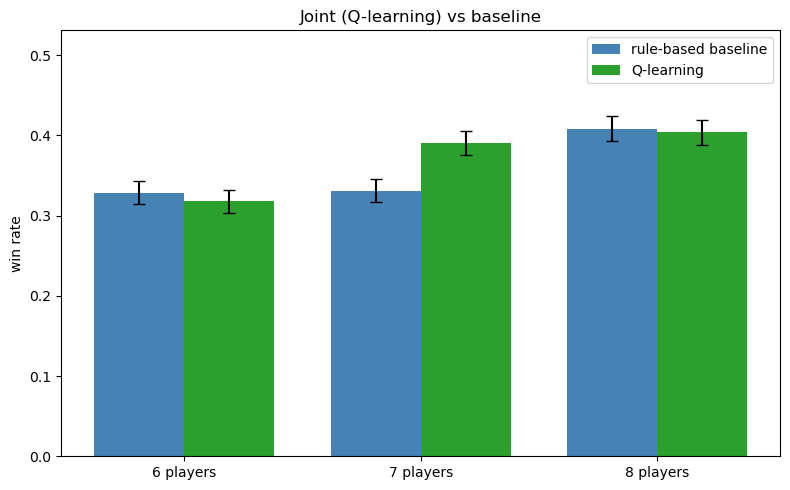

In [3]:
for ablation in ablations:
    summaries_by_player_count = {
        player_count: load_eval(ablation, 'q_learning', player_count)
        for player_count in player_counts
    }
    figure = rl_plots.plot_winrate_comparison(
        summaries_by_player_count,
        title = f'{ablation.replace("_", " ").title()} (Q-learning) vs baseline',
        learned_label = 'Q-learning',
    )
    plt.show()

## Secondary metrics

Win rate is the primary outcome, but the learned policy can also change *how* games are played -
their length, how many boat parts get built, and how much volcano margin remains on a win.

In [4]:
secondary_rows = []
for player_count in player_counts:
    summary = load_eval('joint', 'q_learning', player_count)
    secondary_rows.append({
        'players': player_count,
        'baseline_avg_rounds': round(summary['baseline_secondary']['average_rounds'], 2),
        'learned_avg_rounds': round(summary['rl_secondary']['average_rounds'], 2),
        'baseline_avg_boat_parts': round(summary['baseline_secondary']['average_boat_parts'], 2),
        'learned_avg_boat_parts': round(summary['rl_secondary']['average_boat_parts'], 2),
    })
pd.DataFrame(secondary_rows)

,players,baseline_avg_rounds,learned_avg_rounds,baseline_avg_boat_parts,learned_avg_boat_parts
0,6,15.85,15.37,1.97,1.95
1,7,17.84,17.33,2.85,2.96
2,8,18.90,18.40,3.63,3.72


## Reading the result

The three ablations tell sharply different stories.

- **Mission-only learning beats the baseline at every player count** (win-rate gains of +0.03 to
  +0.11, McNemar $p < 0.001$). Learning *which mission to attempt* from win/loss feedback alone
  outperforms the hand-written `vote_for_mission` heuristic, most strongly at 8 players, where the
  boat is longest and timing matters most.
- **Participant-only learning underperforms the baseline** (-0.03 to -0.10, all significant). The
  shipped `_participant_score` heuristic - affordability, character-ability bonuses, the
  Craftsman-repair penalty, competition - is well tuned, and the coarser learned include/exclude
  ranking does not match it.
- **Joint learning lands in between** (mean +0.02): the mission gains are partly cancelled by the
  weaker staffing, and the two policies learning against one another is non-stationary.

Q-learning and SARSA reach very similar outcomes, as expected when exploration is low late in
training. The clean split - reinforcement learning helps for the high-level mission choice but not
for the already-optimised staffing decision - is examined at the policy level in notebook 5.